,class,count
10,Excel,132
11,Query,72
4,Data Flow Object,44
9,DTP,42
8,Datenvorschau,41
12,Transformationen,39
2,BW4Cockpit (Stammdaten),38
0,ABAP Dictionary,33
6,Data Source,28
3,Composite Provider,17


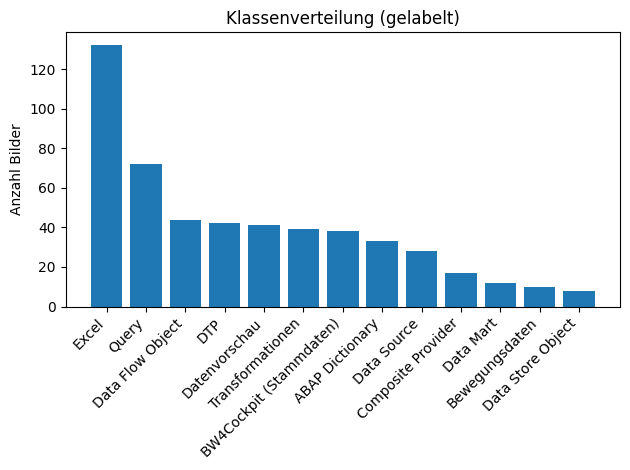

In [35]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("..") / "Data"
LABELED_DIR = DATA_DIR / "SAP Bilder sortiert"

def is_image(p: Path):
    return p.suffix.lower() in {".png",".jpg",".jpeg",".bmp",".webp",".tif",".tiff"}

rows = []
for cls_dir in LABELED_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    n = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))
    rows.append({"class": cls_dir.name, "count": n})

df = pd.DataFrame(rows).sort_values("count", ascending=False)
display(df)

plt.figure()
plt.bar(df["class"], df["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Anzahl Bilder")
plt.title("Klassenverteilung (gelabelt)")
plt.tight_layout()
plt.show()

In [36]:
DATA_DIR = Path("..") / "Data"
LABELED_DIR = DATA_DIR / "SAP Bilder sortiert"

def is_image(p: Path):
    return p.suffix.lower() in {".png",".jpg",".jpeg",".bmp",".webp",".tif",".tiff"}

counts = {}
for cls_dir in LABELED_DIR.iterdir():
    if cls_dir.is_dir():
        counts[cls_dir.name] = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))

s = pd.Series(counts).sort_values(ascending=False)
print("Counts:\n", s)

cap = 75
target = 50

downsample = (s - cap).clip(lower=0).astype(int)      # wie viele entfernen
topup      = (target - s).clip(lower=0).astype(int)   # wie viele ergänzen

print("\nDownsample (remove):\n", downsample[downsample>0])
print("\nTop-up (add via pseudo-labeling):\n", topup[topup>0])
print("\nTotal pseudo-labels needed:", int(topup.sum()))

Counts:
 Excel                      132
Query                       72
Data Flow Object            44
DTP                         42
Datenvorschau               41
Transformationen            39
BW4Cockpit (Stammdaten)     38
ABAP Dictionary             33
Data Source                 28
Composite Provider          17
Data Mart                   12
Bewegungsdaten              10
Data Store Object            8
dtype: int64

Downsample (remove):
 Excel    57
dtype: int64

Top-up (add via pseudo-labeling):
 Data Flow Object            6
DTP                         8
Datenvorschau               9
Transformationen           11
BW4Cockpit (Stammdaten)    12
ABAP Dictionary            17
Data Source                22
Composite Provider         33
Data Mart                  38
Bewegungsdaten             40
Data Store Object          42
dtype: int64

Total pseudo-labels needed: 238


In [37]:
import random

UNLABELED_DIR = DATA_DIR / "Ungelabelt"
SPLITS_DIR = DATA_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

def list_images(folder: Path):
    return sorted([p for p in folder.rglob("*") if p.is_file() and is_image(p)])

unlabeled_all = list_images(UNLABELED_DIR)
print("Unlabeled total:", len(unlabeled_all))

holdout_ratio = 0.50  # mindestens 50% reservieren
seed = 42
rng = random.Random(seed)

idx = list(range(len(unlabeled_all)))
rng.shuffle(idx)

holdout_n = int(len(unlabeled_all) * holdout_ratio)
holdout_idx = set(idx[:holdout_n])

unlabeled_holdout = [unlabeled_all[i] for i in range(len(unlabeled_all)) if i in holdout_idx]
unlabeled_candidate = [unlabeled_all[i] for i in range(len(unlabeled_all)) if i not in holdout_idx]

print("Holdout:", len(unlabeled_holdout))
print("Candidate:", len(unlabeled_candidate))

pd.DataFrame({"path": [str(p) for p in unlabeled_holdout]}).to_csv(SPLITS_DIR / "unlabeled_holdout.csv", index=False)
pd.DataFrame({"path": [str(p) for p in unlabeled_candidate]}).to_csv(SPLITS_DIR / "unlabeled_candidate.csv", index=False)

Unlabeled total: 3135
Holdout: 1567
Candidate: 1568
